# **LAB ASSIGNMENT - 3**

**Install & Import Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


**Data Preparation:**

In [ ]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training shape:", x_train.shape, y_train.shape)

print("Testing shape:", x_test.shape, y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 22s 0us/step
Training shape: (50000, 32, 32, 3) (50000, 10)
Testing shape: (10000, 32, 32, 3) (10000, 10)


**Model Implementation:**

In [ ]:
def build_ann(optimizer='adam', activation='relu'):

    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(512, activation=activation),
        Dense(256, activation=activation),
        Dense(128, activation=activation),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

**Model Training:**

In [ ]:
model = build_ann(optimizer=Adam(), activation='relu')

start_time = time.time()

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

training_time = time.time() - start_time
print("Training time (seconds):", training_time)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.2552 - loss: 2.0511 - val_accuracy: 0.3658 - val_loss: 1.7754
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3828 - loss: 1.7183 - val_accuracy: 0.4008 - val_loss: 1.6675
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.4206 - loss: 1.6121 - val_accuracy: 0.3989 - val_loss: 1.6581
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - accuracy: 0.4396 - loss: 1.5591 - val_accuracy: 0.4441 - val_loss: 1.5662
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.4559 - loss: 1.5130 - val_accuracy: 0.4367 - val_loss: 1.5890
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4755 - loss: 1.4625 - val_accuracy: 0.4613 - val_loss: 1.5258
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.4800 - loss: 1.4361 - val_accuracy: 0.4734 - val_loss: 1.4929
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.4923 - loss: 1.4175 - 

**Model Evaluation:**

Test Accuracy: 0.4977000057697296
Test Loss: 1.4274753332138062
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


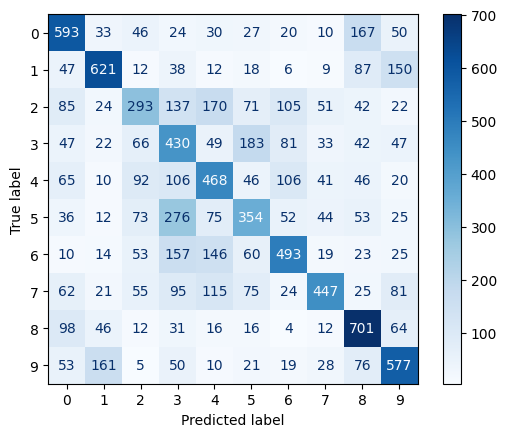

In [ ]:
# Test evaluation
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

# Predictions
y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()


**Performance Comparison:**

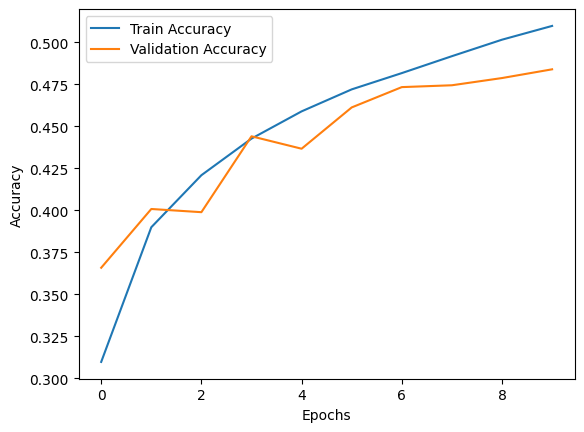

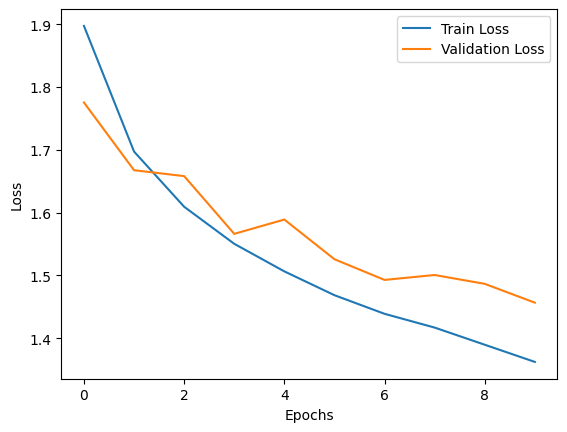

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


**Report:**

In [ ]:
optimizers = {
    "Adam": Adam(),
    "SGD": SGD(),
    "RMSprop": RMSprop()
}

results = {}

for name, opt in optimizers.items():
    model = build_ann(optimizer=opt)
    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results[name] = acc
    print(f"{name} Test Accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Adam Test Accuracy: 0.44909998774528503
SGD Test Accuracy: 0.44749999046325684
RMSprop Test Accuracy: 0.4415000081062317


In [ ]:
print("Model Comparison Summary: \n")

for k, v in results.items():
    print(f"{k} Optimizer Accuracy: {v}")

Model Comparison Summary: 

Adam Optimizer Accuracy: 0.44909998774528503
SGD Optimizer Accuracy: 0.44749999046325684
RMSprop Optimizer Accuracy: 0.4415000081062317


**Summary:**

In this experiment, an ANN was implemented for image classification using the CIFAR-10 dataset, which consists of 60,000 color images belonging to 10 different classes. The dataset was preprocessed by normalizing pixel values to the range [0,1] and converting class labels into one-hot encoded format. A MLP model with three hidden layers was designed and trained using different hyperparameters. The model was trained using the standard training-testing split, and performance was evaluated on unseen test data. Training and validation accuracy and loss curves were plotted to analyze learning behavior and detect overfitting. A confusion matrix was generated to assess class-wise prediction performance. Among the tested configurations, the Adam optimizer showed better convergence and higher accuracy compared to other optimizers. The results demonstrate that a properly tuned ANN can achieve reasonable classification performance on the CIFAR-10 dataset, although deeper models such as CNNs may further improve accuracy.